# What is Dimensionality Reduction?

Dimensionality reduction is the process of reducing the number of input variables or features in a dataset while preserving as much information as possible. This technique is especially useful in:

* **High-dimensional datasets** where many features may be redundant or irrelevant.
* **Visualization**, where reducing data to 2D or 3D allows for plotting.
* **Reducing overfitting** by eliminating noise.
* **Speeding up algorithms** by simplifying computations.

High-dimensional data often suffers from the **curse of dimensionality**, where the distance between data points becomes less meaningful as the number of dimensions increases. Dimensionality reduction helps mitigate this by transforming the data into a lower-dimensional space.

## Principal Component Analysis (PCA)

**Principal Component Analysis (PCA)** is the most commonly used technique for dimensionality reduction. It is an **unsupervised** linear transformation technique that transforms the original features into a new set of **uncorrelated** variables called **principal components (PCs)**.

These components are ordered such that:

* The **first principal component** captures the most variance in the data.
* Each subsequent component captures the maximum remaining variance under the constraint of being orthogonal (i.e., uncorrelated) to the previous components.

PCA is often used in one the following areas:

* Data preprocessing for machine learning

* Visualization of high-dimensional data

* Identifying patterns, clusters, or outliers

* Reducing multicollinearity in regression analysis

It is important to note that PCA simplifies data but you may lose some interpretability, as each principal component is a mixture of the original variables.

# Example
Let's look at an example with the Iris dataset.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
df = sns.load_dataset("iris")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
X = df.drop("species", axis=1)

Before applying the PCA algorithm, you need first standardize your data. This ensures that each variable contributes equally to the analysis. Without scaling, variables with larger numerical ranges will disproportionately influence the direction of the principal components, since PCA maximizes variance.

You can perfom feature scaling using scikit-learn's `StandardScaler` class.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Now that the features have scaled, the next step is to run the PCA algorithm on the scaled dataset.

In [6]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [7]:
X_pca_df = pd.DataFrame(data=X_pca, columns=[f"PC{i+1}" for i in range(X_pca.shape[1])])
X_pca_df.head()

,PC1,PC2,PC3,PC4
0,-2.264703,0.480027,0.127706,-0.024168
1,-2.080961,-0.674134,0.234609,-0.103007
2,-2.364229,-0.341908,-0.044201,-0.028377
3,-2.299384,-0.597395,-0.091290,0.065956
4,-2.389842,0.646835,-0.015738,0.035923


By default the algorithm computes as much principal components as the number features that was passed in.

## Explained variance

After fitting the, you can check the percentage of variance explained by using the `.explained_variance_ratio_` method of your PCA instance.

In [8]:
explained_variance = pd.Series(pca.explained_variance_ratio_, index=[f"PC{i+1}" for i in range(pca.n_components_)])
explained_variance

PC1    0.729624
PC2    0.228508
PC3    0.036689
PC4    0.005179
dtype: float64

Text(0.5, 1.0, 'Cumulative Percentage of Variance Explained')

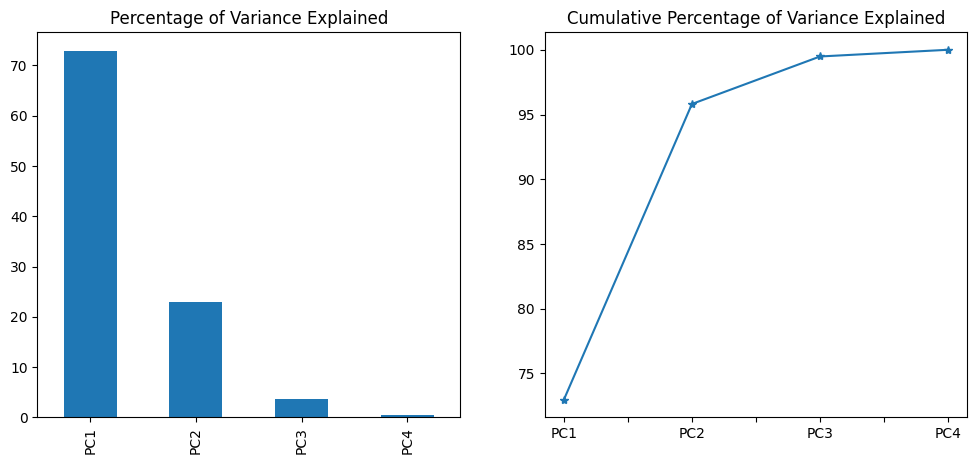

In [9]:
_, ax = plt.subplots(1, 2, figsize=(12, 5))
explained_variance.mul(100).plot(kind="bar", ax=ax[0])
explained_variance.cumsum().mul(100).plot(kind="line", ax=ax[1], marker="*")
ax[0].set_title("Percentage of Variance Explained")
ax[1].set_title("Cumulative Percentage of Variance Explained")

We can see from the figure above that the first principal component captures about 73% of the variation in the data. The second principal component captures about 23% of the variations in the data. Combined together they both capture about 96% of the variations in the dataset.

Since the just two components capture almost all the variation in the data, we could train a model using just two features instead of four. However, keep in mind the in some cases the principal components do not always translate to a good predictor so you still need do some analysis to determine the components might useful predictor variables.

Next, let's see how these components looks like on a 2D plot.

## Visualizing 4D data on 2D Plot

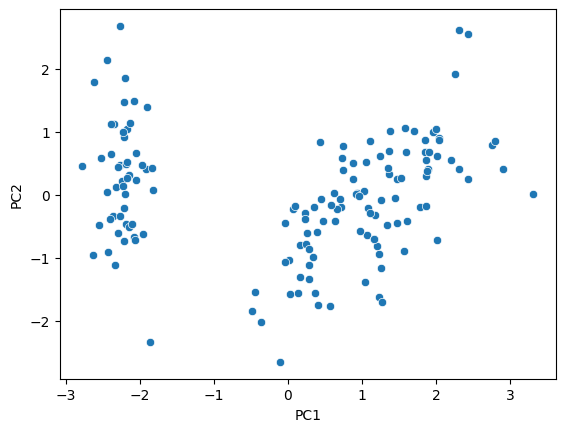

In [10]:
sns.scatterplot(data=X_pca_df, x="PC1", y="PC2");

The plot above shows that the PCA algorithm has captured an underlying grouping in the data. Although we know that the dataset contains different types of flowers, this kind of pattern captured by the PCA algorithm for an uncategorised could be useful for clustering or feature engineering.

## Inspecting the Component Weights

Each principal component is a linear combination (weighted sum) of all features in the dataset. You can inspect the weight by looking at the array store in the `.components_` property.

In [11]:
pd.DataFrame(pca.components_, columns=df.columns[:-1], index=[f"PC{i+1}" for i in range(pca.n_components_)]).T

,PC1,PC2,PC3,PC4
sepal_length,0.521066,0.377418,0.719566,-0.261286
sepal_width,-0.269347,0.923296,-0.244382,0.123510
petal_length,0.580413,0.024492,-0.142126,0.801449
petal_width,0.564857,0.066942,-0.634273,-0.523597


For example each sample in "PCA1" is given by the equation `PCA1 = 0.52 * sepal_length - 0.27 * sepal_width + 0.58 * petal_length + 0.56 * petal_width`.

The magnitude and sign of a component weight tells us the kind of variation it captures.

In "PC1", the sepal length, petal length, and petal width vary in the same direction. This indicates this component captures the fact that flowers with long sepals also tend to have large petals, hence the component is identify flowers that tend to be large in size.

In "PC3" the weight has the magnitudes at sepal length (0.72) and petal width (-0.63), showing this component contrasts sepal length and petal width. This suggests PC3 captures a pattern where longer sepals are associated with smaller petal widths, or vice versa. 

While some principal components might not capture much variation in our data. They could be used as a descriptive technique for identify features that we can add to our dataset.  